### Remboursement d'un prêt immobilier 

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv("Loan_Default.csv")

### Exploration des données (EDA)

In [142]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,75.135870,North,direct,1,39.0
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [143]:
df.shape

(148670, 34)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [67]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [68]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
LTV                          10.155378
property_value               10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
Region                        0.000000
total_units                   0.000000
Security_Type                 0.000000
Status                        0.000000
co-applicant_credit_type      0.000000
Credit_Score                  0.000000
credit_type                   0.000000
ID                            0.000000
Secured_by                    0.000000
occupancy_type                0.000000
construction_type             0.000000
year                     

In [141]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

### Prétraitement des données

In [69]:

import pandas as pd
import numpy as np

numeric_cols = [
    'Upfront_charges',
    'Interest_rate_spread',
    'rate_of_interest',
    'dtir1',
    'LTV',
    'property_value',
    'income',
    'term'
]

for col in numeric_cols:
  df[col] = df[col].fillna(df[col].median())


In [70]:
import pandas as pd
import numpy as np


categorical_cols = [
    'loan_limit',
    'approv_in_adv',
    'submission_of_application',
    'age',
    'loan_purpose',
    'Neg_ammortization'
]

for col in categorical_cols:
   df[col] = df[col].fillna(df[col].mode()[0])


In [71]:
print(df.isnull().sum())

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 148670 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              148670 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148670 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           148670 non-null  float64
 12  Interest_rate_spread       148670 non-null  float64
 13  Upfront_charges            14

In [73]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [74]:
df_encoded.head()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
0,24890,2019,116500,3.99,0.3904,2596.45,360.0,118000.0,1740.0,758,...,False,False,False,False,False,True,False,False,True,True
1,24891,2019,206500,3.99,0.3904,2596.45,360.0,418000.0,4980.0,552,...,False,True,False,False,False,True,False,False,False,True
2,24892,2019,406500,4.56,0.2000,595.00,360.0,508000.0,9480.0,834,...,False,False,False,False,False,True,False,False,True,True
3,24893,2019,456500,4.25,0.6810,2596.45,360.0,658000.0,11880.0,587,...,True,False,False,False,False,False,False,False,False,True
4,24894,2019,696500,4.00,0.3042,0.00,360.0,758000.0,10440.0,602,...,False,False,False,False,False,False,False,False,False,True


In [75]:
df_encoded.shape

(148670, 51)

In [76]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 51 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ID                                 148670 non-null  int64  
 1   year                               148670 non-null  int64  
 2   loan_amount                        148670 non-null  int64  
 3   rate_of_interest                   148670 non-null  float64
 4   Interest_rate_spread               148670 non-null  float64
 5   Upfront_charges                    148670 non-null  float64
 6   term                               148670 non-null  float64
 7   property_value                     148670 non-null  float64
 8   income                             148670 non-null  float64
 9   Credit_Score                       148670 non-null  int64  
 10  LTV                                148670 non-null  float64
 11  Status                             1486

In [77]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

### Vérification du corrélation 

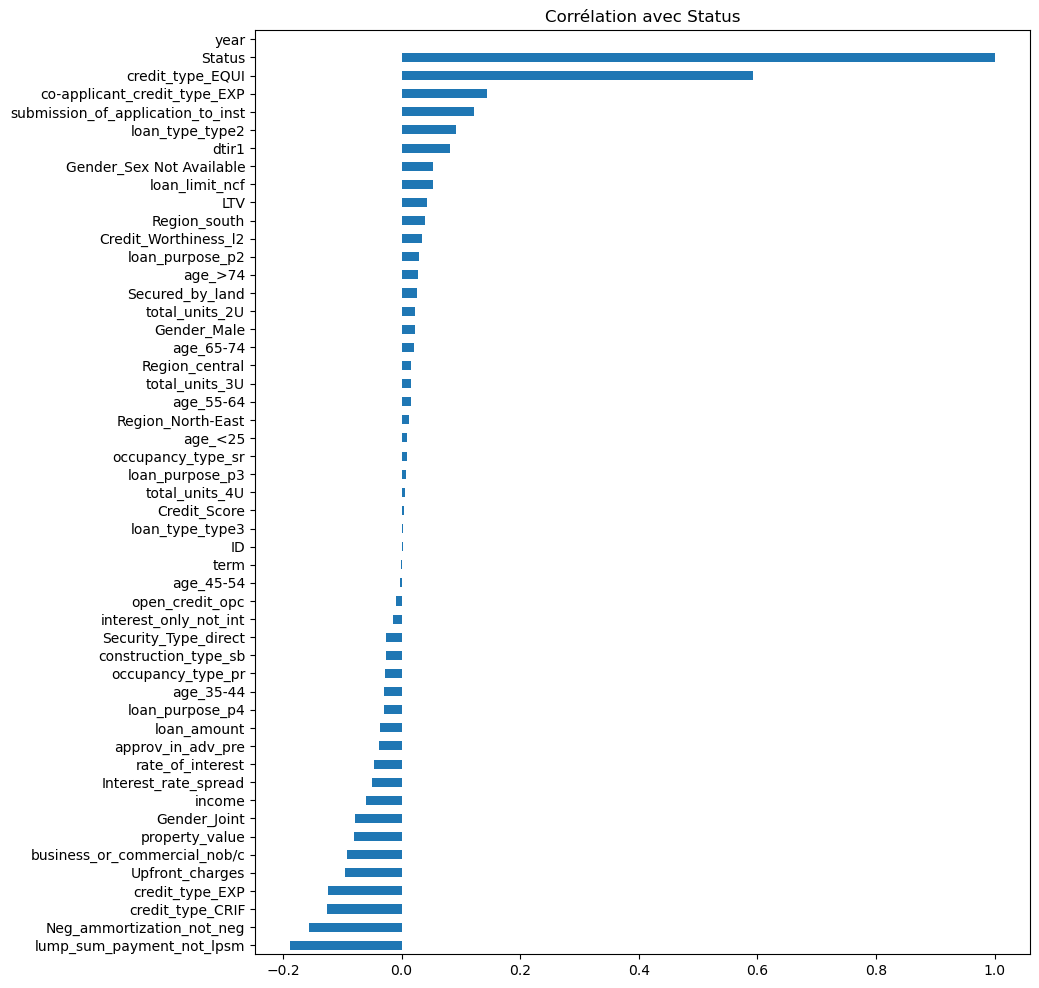

In [78]:
corr = df_encoded.corr()['Status'].sort_values()

plt.figure(figsize=(10,12))

corr.plot(kind='barh')

plt.title('Corrélation avec Status')

plt.show()

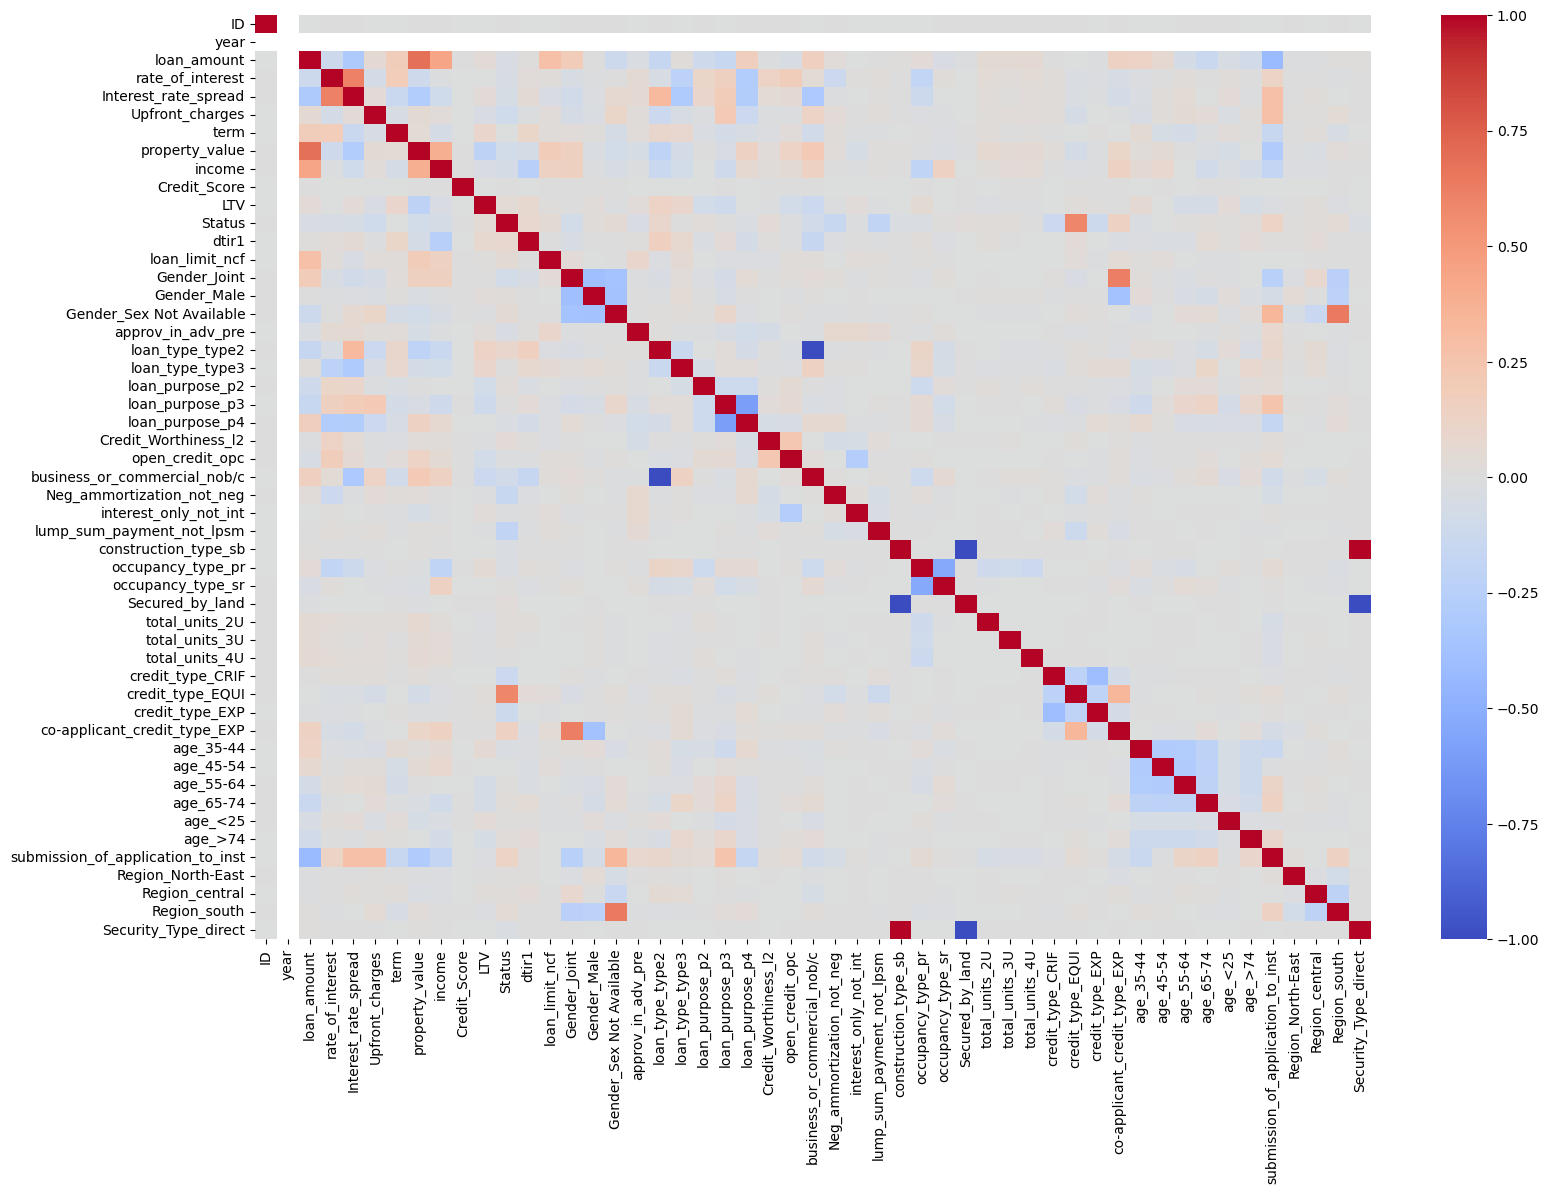

In [79]:
plt.figure(figsize=(18,12))

sns.heatmap(df_encoded.corr(), cmap='coolwarm')

plt.show()

In [80]:
corr = df_encoded.corr()['Status'].sort_values(ascending=False)

print(corr)

Status                               1.000000
credit_type_EQUI                     0.592168
co-applicant_credit_type_EXP         0.144239
submission_of_application_to_inst    0.122410
loan_type_type2                      0.092550
dtir1                                0.082432
Gender_Sex Not Available             0.053336
loan_limit_ncf                       0.053332
LTV                                  0.042656
Region_south                         0.040051
Credit_Worthiness_l2                 0.034875
loan_purpose_p2                      0.029369
age_>74                              0.028021
Secured_by_land                      0.026055
total_units_2U                       0.022978
Gender_Male                          0.022653
age_65-74                            0.020665
Region_central                       0.016738
total_units_3U                       0.016460
age_55-64                            0.015257
Region_North-East                    0.012320
age_<25                           

### Préparation de X et Y 

In [81]:
X = df_encoded.drop(['Status', 'ID'], axis=1)

y = df_encoded['Status']

In [82]:
print(X.columns.tolist())

['year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1', 'loan_limit_ncf', 'Gender_Joint', 'Gender_Male', 'Gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2', 'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3', 'loan_purpose_p4', 'Credit_Worthiness_l2', 'open_credit_opc', 'business_or_commercial_nob/c', 'Neg_ammortization_not_neg', 'interest_only_not_int', 'lump_sum_payment_not_lpsm', 'construction_type_sb', 'occupancy_type_pr', 'occupancy_type_sr', 'Secured_by_land', 'total_units_2U', 'total_units_3U', 'total_units_4U', 'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP', 'co-applicant_credit_type_EXP', 'age_35-44', 'age_45-54', 'age_55-64', 'age_65-74', 'age_<25', 'age_>74', 'submission_of_application_to_inst', 'Region_North-East', 'Region_central', 'Region_south', 'Security_Type_direct']


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [84]:
#Standardisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Modèle - 1  : Logistic Regression

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [86]:
y_pred_log = model.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy : 0.8713593865608394
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22494
           1       0.93      0.51      0.66      7240

    accuracy                           0.87     29734
   macro avg       0.89      0.75      0.79     29734
weighted avg       0.88      0.87      0.86     29734



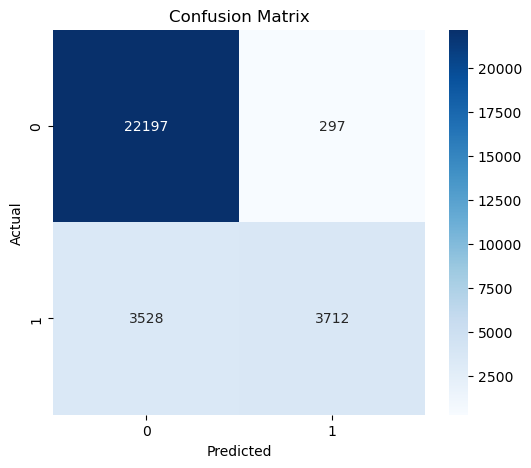

In [88]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

### Modèl 2 - Decision Tree

In [89]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [90]:
y_pred_dt = dt_model.predict(X_test)

In [91]:

print("Decision Tree Accuracy :", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy : 0.9999663684670748
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       1.00      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



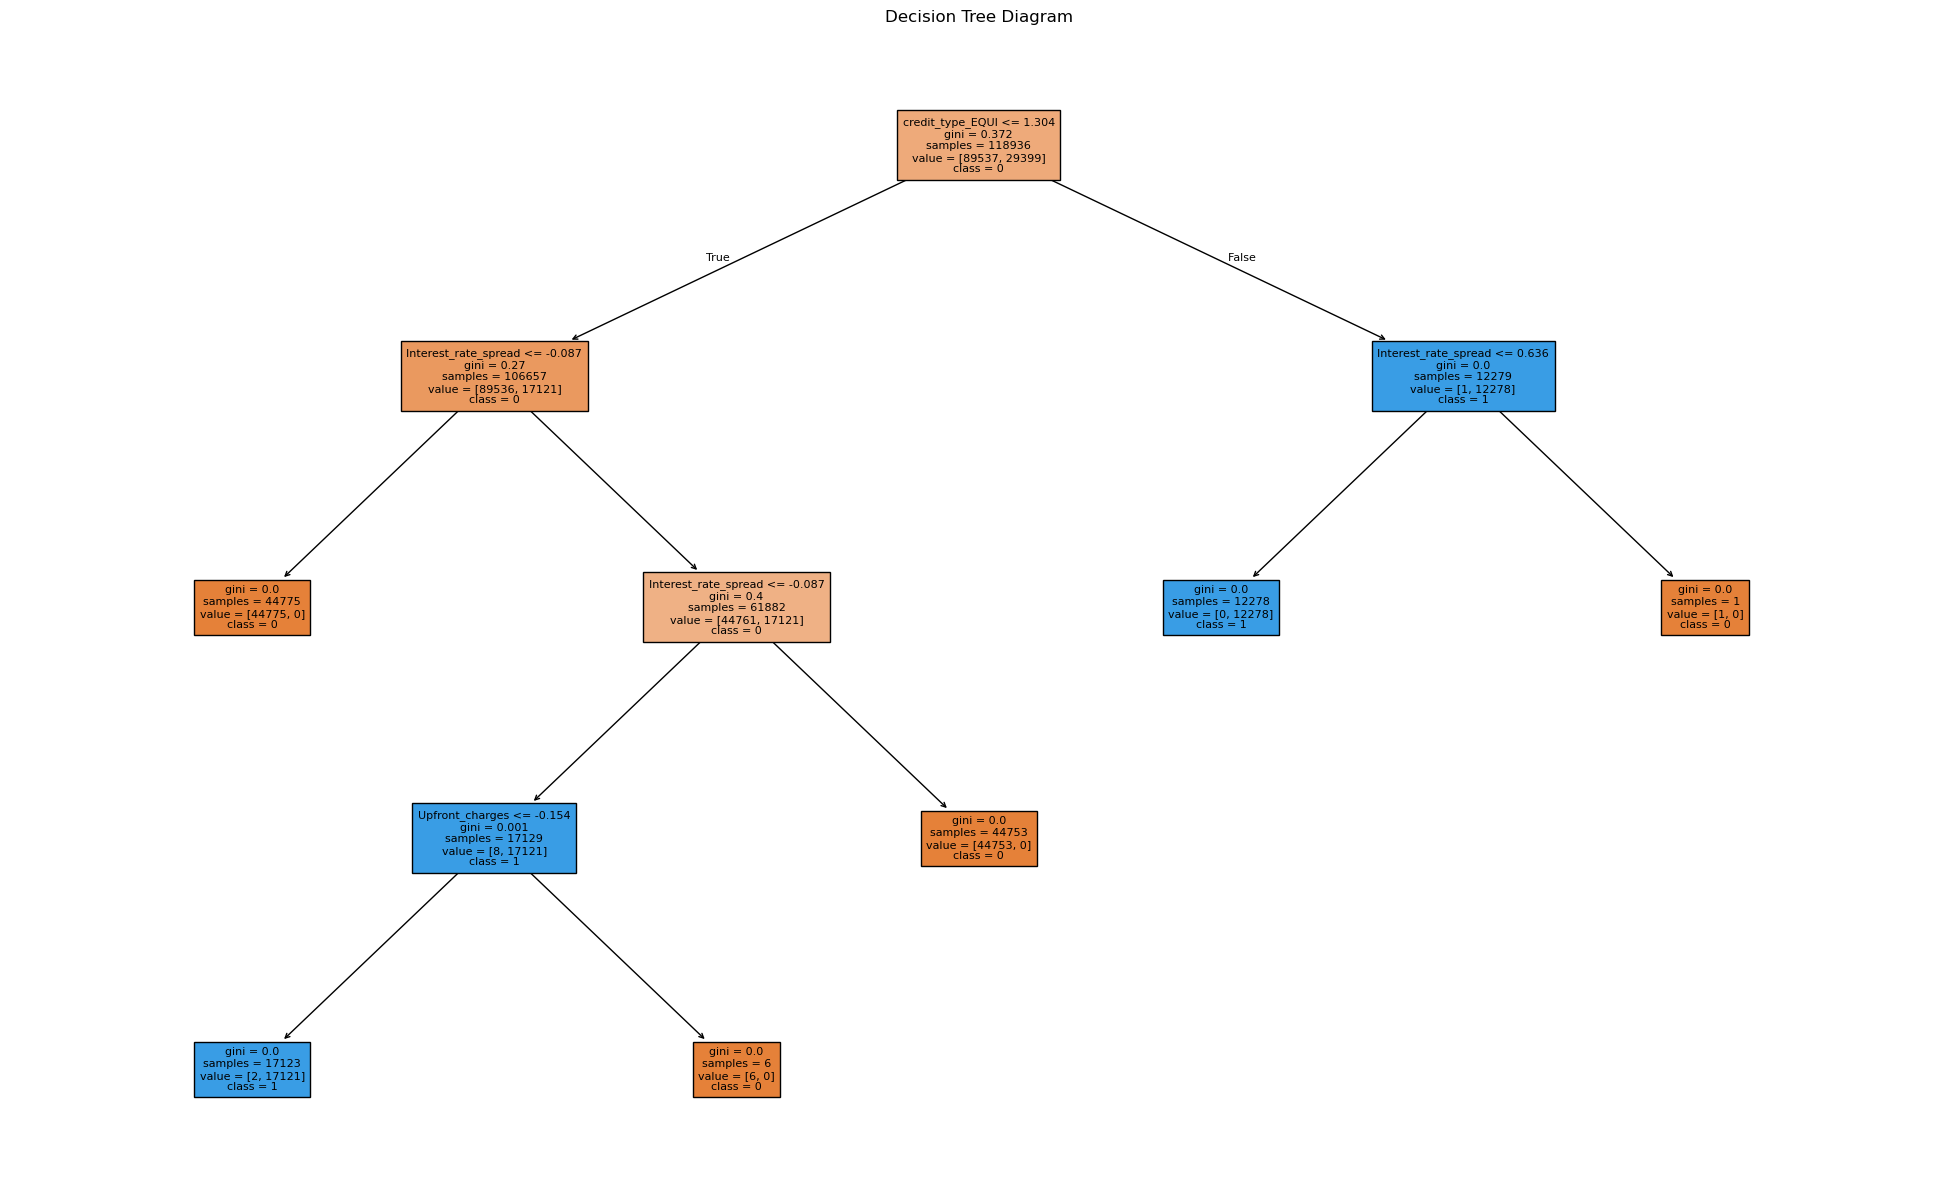

In [92]:
plt.figure(figsize=(25,15))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Diagram")

plt.show()

### Modèl 3 - Random Forest

In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(pd.Series(y_pred_rf).value_counts())


0    22493
1     7241
Name: count, dtype: int64


In [120]:
y_pred_rf = rf_model.predict(X_test)

In [121]:
print("Random Forest Accuracy :", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy : 0.9999663684670748
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       1.00      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



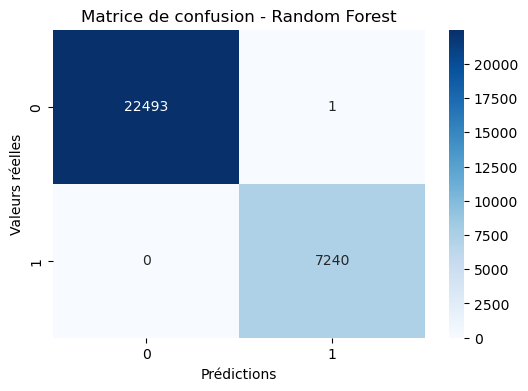

In [122]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)

# Affichage
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Random Forest")

plt.show()

In [123]:
corr = df_encoded.corr(numeric_only=True)['Status'].sort_values(ascending=False)

print(corr.head(20))

Status                               1.000000
credit_type_EQUI                     0.592168
co-applicant_credit_type_EXP         0.144239
submission_of_application_to_inst    0.122410
loan_type_type2                      0.092550
dtir1                                0.082432
Gender_Sex Not Available             0.053336
loan_limit_ncf                       0.053332
LTV                                  0.042656
Region_south                         0.040051
Credit_Worthiness_l2                 0.034875
loan_purpose_p2                      0.029369
age_>74                              0.028021
Secured_by_land                      0.026055
total_units_2U                       0.022978
Gender_Male                          0.022653
age_65-74                            0.020665
Region_central                       0.016738
total_units_3U                       0.016460
age_55-64                            0.015257
Name: Status, dtype: float64


### Modèl 4 - KNN

In [124]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['Status', 'ID'], axis=1)
y = df_encoded['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [126]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.8869980493710903

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     22494
           1       0.83      0.67      0.74      7240

    accuracy                           0.89     29734
   macro avg       0.87      0.81      0.84     29734
weighted avg       0.88      0.89      0.88     29734



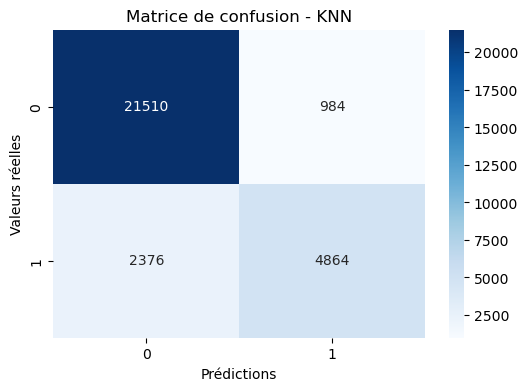

In [127]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - KNN")

plt.show()

In [128]:
for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    print(f"K = {k} --> Accuracy = {accuracy_score(y_test, y_pred_knn):.4f}")

K = 3 --> Accuracy = 0.8812
K = 5 --> Accuracy = 0.8870
K = 7 --> Accuracy = 0.8898
K = 9 --> Accuracy = 0.8911
K = 11 --> Accuracy = 0.8913


### Modèl 5 - Naive Bayes

In [129]:
# 1. Importer les bibliothèques
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Créer le modèle Naive Bayes
nb_model = GaussianNB()

# 3. Entraîner le modèle
nb_model.fit(X_train, y_train)

# 4. Faire les prédictions
y_pred_nb = nb_model.predict(X_test)

# 5. Calculer l'accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy Naive Bayes :", accuracy_nb)

Accuracy Naive Bayes : 0.9158202730880474


In [130]:
# 6. Afficher le rapport de classification
print("Classification Report - Naive Bayes")
print(classification_report(y_test, y_pred_nb))

Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     22494
           1       0.75      0.99      0.85      7240

    accuracy                           0.92     29734
   macro avg       0.87      0.94      0.90     29734
weighted avg       0.94      0.92      0.92     29734



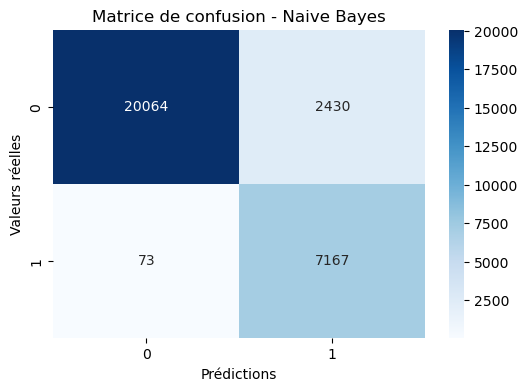

In [131]:
# 7. Matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Naive Bayes")

plt.show()

### Modèl 6 - SVM

In [133]:

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Normalisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle SVM rapide
svm_model = LinearSVC(random_state=42, max_iter=5000)

# Entraînement
svm_model.fit(X_train_scaled, y_train)

# Prédiction
y_pred_svm = svm_model.predict(X_test_scaled)


In [134]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy SVM :", accuracy_svm)

Accuracy SVM : 0.8666173404183762


Classification Report - SVM
              precision    recall  f1-score   support

           0       0.85      0.99      0.92     22494
           1       0.96      0.47      0.63      7240

    accuracy                           0.87     29734
   macro avg       0.91      0.73      0.78     29734
weighted avg       0.88      0.87      0.85     29734



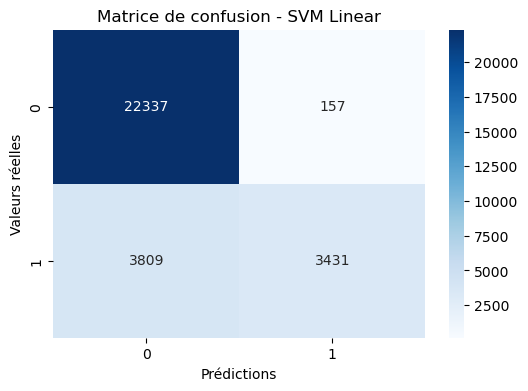

In [135]:
print("Classification Report - SVM")
print(classification_report(y_test, y_pred_svm))

# Matrice de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - SVM Linear")
plt.show()

In [136]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Modèle': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Naive Bayes',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm)
    ]
})

results = results.sort_values(by='Accuracy', ascending=False)

print(results)

                Modèle  Accuracy  Precision    Recall  F1-Score
1        Decision Tree  0.999966   0.999862  1.000000  0.999931
2        Random Forest  0.999966   0.999862  1.000000  0.999931
4          Naive Bayes  0.915820   0.746796  0.989917  0.851339
3                  KNN  0.891337   0.895287  0.627072  0.737552
0  Logistic Regression  0.871359   0.925917  0.512707  0.659970
5                  SVM  0.866617   0.956243  0.473895  0.633727


In [137]:
print(len(X.columns))
print(len(rf_model.feature_importances_))

49
49


### Conclusion Finale

##### Plusieurs modèles de classification ont été évalués : Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes et SVM. Les meilleurs résultats ont été obtenus avec Decision Tree et Random Forest, qui ont atteint une accuracy de 99.99 % ainsi qu'un F1-score de 99.99 %. Ces modèles ont donc été retenus comme les plus performants pour la prédiction de la variable cible Status.

### Enregistrement du modèl 

In [138]:
import joblib

# Sauvegarder le meilleur modèle
joblib.dump(rf_model, "best_model_random_forest.pkl")

# Sauvegarder les colonnes utilisées pendant l'entraînement
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']